# Customer Churn Prediction

The objective of this project is to understand the factors associated with customer churn
and develop a classification model that can identify customers at higher risk of leaving.

This notebook is a reproducible presentation layer for the source-code pipeline. The model predicts customer churn and selects the candidate with the highest validation F1 score.

**Important:** transformations that learn values (imputation, scaling, encoding) are fitted only on training data to prevent leakage.

### Key Questions

- What is the overall customer churn rate?
- Does churn differ by gender or customer segment?
- Which contract and service types are associated with higher churn?
- Which services are associated with higher customer spending?
- How do tenure and monthly charges relate to churn?

Workflow

- Data Loading
- Exploratory Data Analysis
- Data Cleaning
- Feature Engineering
- Train / Validation / Test Split
- Preprocessing
- Model Training
- Model Comparison
- Final Evaluation

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [2]:
import pandas as pd
import numpy as np

from src.data_loader import load_data
from src.preprocessing import convert_numeric_columns, clean_data
from src.feature_engineering import feature_engineering
from src.preprocessing import (
    drop_columns,
    encode_target,
    data_target_split,
    train_val_test_split,
    build_preprocessor, 
    fill_missing_values
)

from src.modeling import (
    build_models,
    train_models,
    select_best_model
)

from src.evaluation import (
    evaluate_validation,
    evaluate_models_on_test
)

from src.visualization import *

from src.utils import get_numeric_cols, get_categorical_cols

from src.eda import *

from src.config import DROP_COLS

pd.set_option('display.max_columns', None)

## Loading & Understanding Dataset 

Before cleaning the data, we inspect its structure and quality.

In [3]:
df = load_data()

df.head()

Data loaded successfully. rows:7043, columns:21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

### Describe numeric features:

In [8]:
# df.describe().T
numeric_summary(df)

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


Label encoder should be applied to ``SeniorCitizen`` column 

### Describe categoric features:


In [9]:
categorical_summary(df)

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


## Data Quality

In [10]:
missing_val = get_missing_values(df)
duplicated = check_duplicates(df)
if len(missing_val)>0:
    print(f"Missing Values:  {len(missing_val)}")
else: 
    print("No missing value")

if duplicated>0:
    print(f"Duplicated Rows: {duplicated}")
else: 
    print("No Duplicated row")

No missing value
No Duplicated row


In [11]:
df.nunique().sort_values(ascending=False)

customerID          7043
TotalCharges        6531
MonthlyCharges      1585
tenure                73
PaymentMethod          4
StreamingMovies        3
TechSupport            3
OnlineBackup           3
StreamingTV            3
DeviceProtection       3
MultipleLines          3
InternetService        3
OnlineSecurity         3
Contract               3
Partner                2
SeniorCitizen          2
gender                 2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
dtype: int64

The number of rows matches that of `customerID`, but `TotalCharges` does not match. Even though there are no missing values, there may be `NaN` values, and a type conversion might be necessary.

## Data Type Validation

In [12]:
df["TotalCharges"].head()

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: str

In [13]:
df["TotalCharges"].dtypes

<StringDtype(storage='python', na_value=nan)>

In [14]:
df = convert_numeric_columns(df,"TotalCharges")
df["TotalCharges"].dtypes

dtype('float64')

``TotalCharges`` column should be checked after converting it to a numeric format.

In [15]:
missing_val = get_missing_values(df)
missing_val

TotalCharges    11
dtype: int64

In [16]:
df[np.isnan(df["TotalCharges"])]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


There are 0 values ​​in the ``tenure`` column, even though ``monthlycharges`` is not 0.

``tenure`` = 0 row indexes:

In [17]:
df[df["tenure"] == 0].index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

In [18]:
len(df[df["tenure"] == 0].index)

11

In [19]:
df = fill_missing_values(df)

In [20]:
df[np.isnan(df["TotalCharges"])]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [21]:
df["SeniorCitizen"]= df["SeniorCitizen"].map({0: "No", 1: "Yes"})
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Cleaning

In [22]:
df = clean_data(df)

In [23]:
df["customerID"].nunique()

7043

``customerID`` does not provide generalizable information for churn prediction and is therefore excluded from the model features.

In [24]:
df = drop_columns(df, DROP_COLS)
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

## Exploratory Data Analysis

### Churn Overview

In [25]:
churn_count = get_target_count(df)
churn_count

Churn
No     5174
Yes    1869
Name: count, dtype: int64

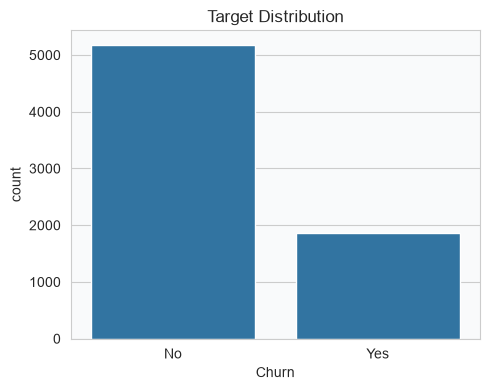

In [26]:
plot_target_distribution(df)

In [27]:
churn_rate = target_distribution(df)
churn_rate

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

The customer churn rate is 26–27%. Since the dataset is imbalanced, precision, recall, and F1 score metrics should be prioritized over simple accuracy when evaluating the model.

### Churn by Customer Characteristics

In [28]:
churn_by_seniorCitizen = churn_rate_by_category(df, "SeniorCitizen")
churn_by_seniorCitizen

Churn,No,Yes
SeniorCitizen,,
No,76.39,23.61
Yes,58.32,41.68


In [29]:
churn_by_gender = churn_rate_by_category(df,"gender")
churn_by_gender

Churn,No,Yes
gender,,
Female,73.08,26.92
Male,73.84,26.16


In [30]:
churn_by_partner = churn_rate_by_category(df, "Partner")
churn_by_partner

Churn,No,Yes
Partner,,
No,67.04,32.96
Yes,80.34,19.66


In [31]:
churn_by_dependents = churn_rate_by_category(df, "Dependents")
churn_by_dependents

Churn,No,Yes
Dependents,,
No,68.72,31.28
Yes,84.55,15.45


Gender does not affect churn, as male and female rates are nearly identical. However, senior citizens, customers without partners, and those without dependents have much higher churn rates and are more likely to leave.

### Churn by Contract & Services

In [32]:
churn_by_paymentMethod = churn_rate_by_category(df,"PaymentMethod")
churn_by_paymentMethod

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


In [33]:
churn_by_internetService = churn_rate_by_category(df,"InternetService")
churn_by_internetService 

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


In [34]:
churn_by_contract = churn_rate_by_category(df, "Contract")
churn_by_contract 

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


In [60]:
service_cols = ["PhoneService", "MultipleLines", "OnlineSecurity",
                "OnlineBackup", "DeviceProtection", "TechSupport",
                "StreamingTV", "StreamingMovies"]

for col in service_cols:
    print(f"--- {col} ---")
    print(churn_rate_by_category(df, col))
    print()

--- PhoneService ---
Churn             0      1
PhoneService              
No            75.07  24.93
Yes           73.29  26.71

--- MultipleLines ---
Churn                 0      1
MultipleLines                 
No                74.96  25.04
No phone service  75.07  24.93
Yes               71.39  28.61

--- OnlineSecurity ---
Churn                    0      1
OnlineSecurity                   
No                   58.23  41.77
No internet service  92.60   7.40
Yes                  85.39  14.61

--- OnlineBackup ---
Churn                    0      1
OnlineBackup                     
No                   60.07  39.93
No internet service  92.60   7.40
Yes                  78.47  21.53

--- DeviceProtection ---
Churn                    0      1
DeviceProtection                 
No                   60.87  39.13
No internet service  92.60   7.40
Yes                  77.50  22.50

--- TechSupport ---
Churn                    0      1
TechSupport                      
No                   5

Churn is highest among month-to-month, fiber optic, and electronic check users. Additionally, lacking Online Security or Tech Support significantly increases churn risk, proving that missing add-on services triggers cancellations.

### Revenue / Spending Analysis

Service segments with the highest average/total monthly revenue

In [38]:
revenue_by_internetService = revenue_by_segment(
    df, col="InternetService", revenue_col="MonthlyCharges"
)
revenue_by_internetService

,mean,sum,count
InternetService,,,
Fiber optic,91.500129,283284.40,3096
DSL,58.102169,140665.35,2421
No,21.079194,32166.85,1526


In [39]:
revenue_by_paymentMethod = revenue_by_segment(
    df, col="PaymentMethod", revenue_col="MonthlyCharges"
)
revenue_by_paymentMethod

,mean,sum,count
PaymentMethod,,,
Electronic check,76.255814,180345.00,2365
Bank transfer (automatic),67.192649,103745.45,1544
Credit card (automatic),66.512385,101231.85,1522
Mailed check,43.917060,70794.30,1612


In [40]:
revenue_by_techSupport = revenue_by_segment(
    df, col="TechSupport", revenue_col="MonthlyCharges"
)
revenue_by_techSupport

,mean,sum,count
TechSupport,,,
No,74.586683,259039.55,3473
Yes,80.680137,164910.20,2044
No internet service,21.079194,32166.85,1526


High revenue segments with high churn rates are the primary area of ​​risk.

Fiber optic and premium add-on users bring the most revenue. Since fiber optic has both high revenue and high churn, retaining these customers is the primary priority.

## Numerical Analysis

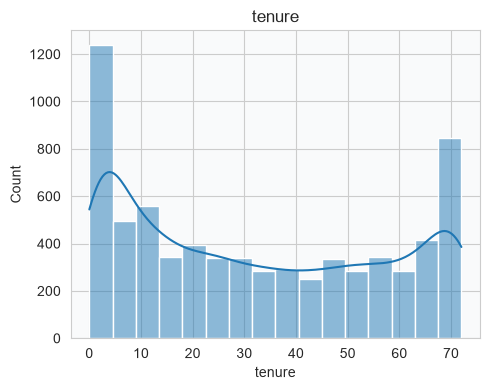

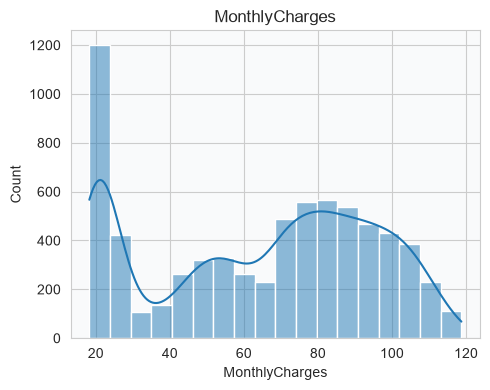

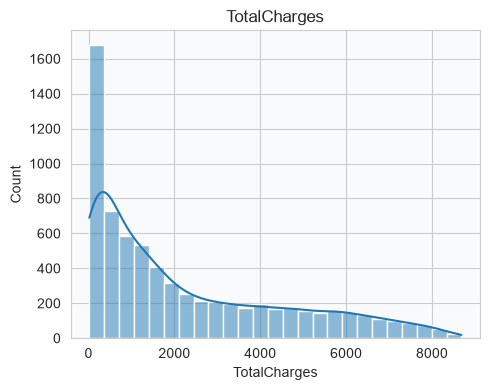

In [41]:
plot_numeric_distribution(df)

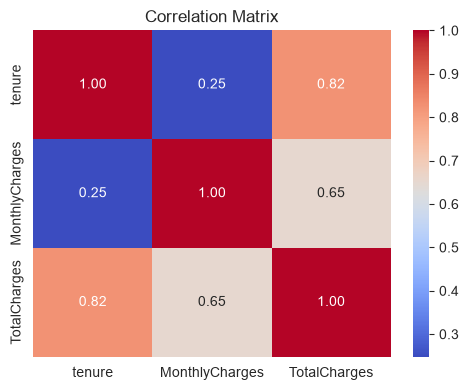

In [42]:
plot_correlation_heatmap(df)

In [43]:
plot_missing_values(df)

There is no empty value..


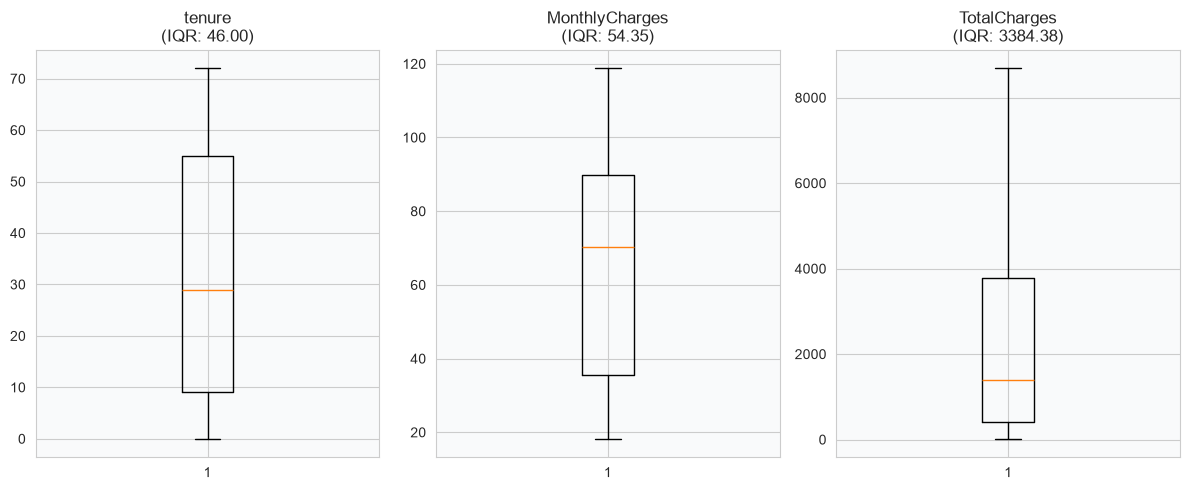

In [44]:
numeric_cols = get_numeric_cols(df)
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(4 * len(numeric_cols), 5))

for i,col in enumerate(numeric_cols):
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3- q1
        lower_bound = q1 -1.5 * iqr
        upper_bound = q3 +1.5 * iqr
        axes[i].boxplot(df[col].dropna())
        axes[i].set_title(f"{col}\n(IQR: {iqr:.2f})")
plt.tight_layout()
plt.show()


### Churn-Tenure & Monthly Charges

In [45]:
df.groupby("Churn")[["tenure","MonthlyCharges"]].mean()

,tenure,MonthlyCharges
Churn,,
No,37.569965,61.265124
Yes,17.979133,74.441332


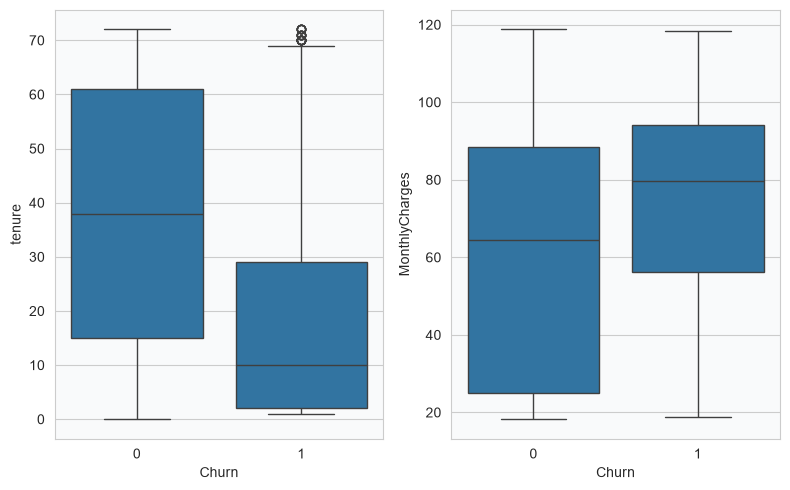

In [64]:
fig, ax = plt.subplots(1,2, figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="tenure", ax=ax[0])
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=ax[1])
plt.tight_layout()
plt.show()

Churned customers have a shorter retention period and higher monthly costs. Since new and high-spending customers are the highest-risk group, the ``IsNewCustomer`` and ``AverageMonthlySpend`` attributes can be developed.

## Feature Engineering

In [46]:
# Type Conversion
df = convert_numeric_columns(df, "TotalCharges")

df = feature_engineering(df)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,IsMonthToMonth,HasTechSupport,IsNewCustomer,AverageMonthlySpend
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1,0,1,29.850000
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0,0,0,55.573529
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0,1,54.075000
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,1,0,40.905556
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0,1,75.825000


## Train Validation Test Split

In [47]:
df = encode_target(df)

X, y = data_target_split(df)

X_train, X_val, X_test, y_train, y_val, y_test = train_val_test_split(X,y)

## Data Preprocessing

In [48]:
numeric_cols = get_numeric_cols(X_train)

categorical_cols = get_categorical_cols(X_train)

preprocessor = build_preprocessor(
    numeric_cols,
    categorical_cols
)

In [49]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

## Model Training

In [50]:
models = build_models()

In [51]:
validation_results = []

for name, model in models.items():

    trained_model = train_models(
        model,
        X_train_processed,
        y_train
    )

    result = evaluate_validation(
        trained_model,
        X_val_processed,
        y_val
    )

    result["model_name"] = name
    
    result["trained_model"] = trained_model

    validation_results.append(result)

## Validation Results

In [52]:
pd.DataFrame(validation_results)

,accuracy,precision,recall,f1,confusion_matrix,model_name,trained_model
0,0.745919,0.514134,0.778075,0.619149,"[[760, 275], [83, 291]]",Logistic Regression,"LogisticRegression(class_weight='balanced', ma..."
1,0.769340,0.568245,0.545455,0.556617,"[[880, 155], [170, 204]]",KNN,KNeighborsClassifier()
2,0.743080,0.515957,0.518717,0.517333,"[[853, 182], [180, 194]]",Decision Tree,DecisionTreeClassifier(random_state=42)


## Best Model

In [53]:
best_result = select_best_model(validation_results)

best_model = best_result["trained_model"]

best_result

{'accuracy': 0.7459190915542938,
 'precision': 0.5141342756183745,
 'recall': 0.7780748663101604,
 'f1': 0.6191489361702127,
 'confusion_matrix': array([[760, 275],
        [ 83, 291]]),
 'model_name': 'Logistic Regression',
 'trained_model': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)}

## Test Evaluation

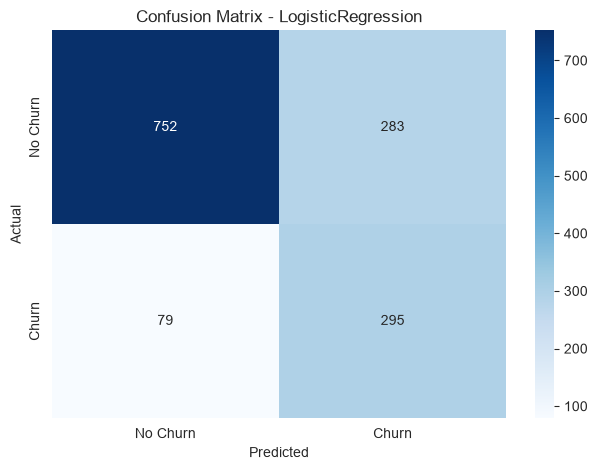

In [54]:
test_results = evaluate_models_on_test(
    best_model,
    X_test_processed,
    y_test
)

- TN = 752: Correctly identified 752 of the 1,035 customers who did not actually churn.
- FP = 283: Incorrectly predicted that 283 customers who did not churn had churned.
- FN = 79: Failed to identify 79 of the actual churn customers.
- TP = 295: Correctly identified 295 of the actual churn customers.

In [55]:
pd.DataFrame([{
    "accuracy": test_results["accuracy"],
    "precision": test_results["precision"],
    "recall": test_results["recall"],
    "f1": test_results["f1"]
}])

,accuracy,precision,recall,f1
0,0.74308,0.510381,0.78877,0.619748


## Conclusion

Based on the validation results, the model with the highest F1-score was selected and finally evaluated on a previously unseen test set. Given that the churn problem is specifically an imbalanced classification task, the focus was placed not only on accuracy but also on precision, recall, and F1-score metrics.

In the validation results, Logistic Regression was the model that performed best, with an F1-score of 0.619. The fact that the model achieved 74.6% accuracy and 77.8% recall indicates that it was able to identify a large proportion of customers who would churn. Conversely, the precision value of 51.4% indicates that some of the customers the model predicted would churn did not actually churn.